In [93]:
import numpy as np
import matplotlib.pyplot as plt
import csv

# Case Study

## Sensitivity Comparison for Q1-Q4

In [94]:
plt.rcParams.update({'font.size': 20})

def read_sensitivity(filepath):
    with open(filepath, newline='') as f:
        reader = csv.reader(f)
        data = []
        for row in reader:
            if not row:
                continue
            data.append(int(row[1]))    
        return data

In [101]:
# Constants
policies = np.array([r'$\mathcal{P}^U_{R_1}$', r'$\mathcal{P}^B_{R_1}$', r'$\mathcal{P}^1_{R_1}$', r'$\mathcal{P}^2_{R_1}$'])
queries = ['$Q1$', '$Q2$', '$Q3$', '$Q4$']
colors = ['lightgray', 'darkgray', 'darkslategray']
n_groups = 4
n_subgroups = 3
x = np.arange(n_groups)
bar_width = 0.25

# Data
data = []
data.append(read_sensitivity('university/q1_sensitivity.csv'))
data.append(read_sensitivity('university/q2_sensitivity.csv'))
data.append(read_sensitivity('university/q3_sensitivity.csv'))
data.append(read_sensitivity('university/q4_sensitivity.csv'))
data = np.array(data)

p1_data = np.delete(data, 3, axis=1)
p2_data = np.delete(data, 2, axis=1)

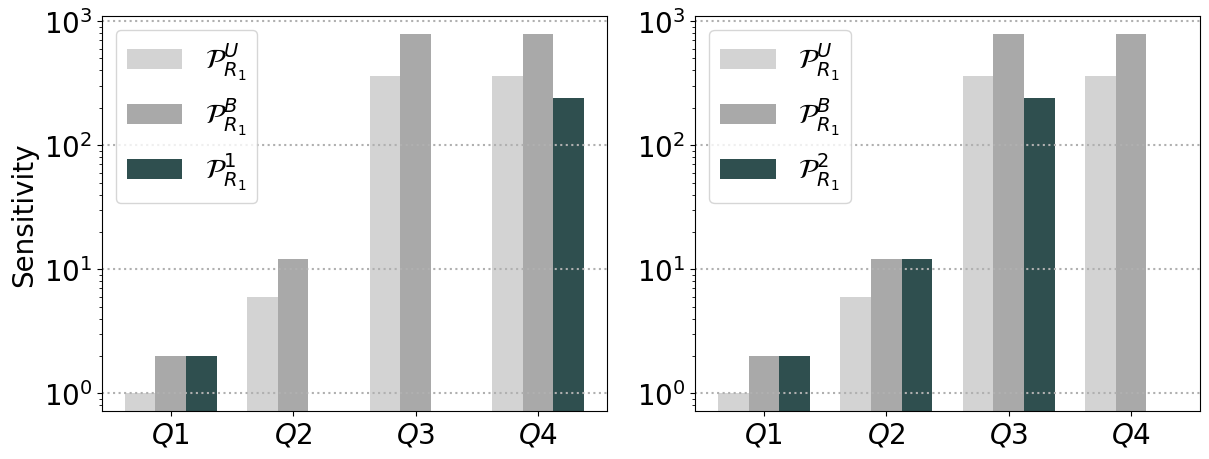

In [102]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# Plot 1
p1_policies = np.delete(policies, 3)

for i in range(n_subgroups):
    ax1.bar(x + i * bar_width, p1_data[:, i], width=bar_width, label=p1_policies[i], color=colors[i])

ax1.set_ylabel('Sensitivity')
ax1.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax1.set_xticklabels(queries)
ax1.set_yscale('log')
ax1.legend(ncol=1, loc='upper left')
ax1.grid(axis='y', linestyle=':', linewidth=1.5)

# Plot 2
p2_policies = np.delete(policies, 2)

for i in range(n_subgroups):
    ax2.bar(x + i * bar_width, p2_data[:, i], width=bar_width, label=p2_policies[i], color=colors[i])

ax2.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax2.set_xticklabels(queries)
ax2.set_yscale('log')
ax2.legend(ncol=1, loc='upper left')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)

plt.tight_layout()
plt.show()

## Noise Comparison for Q5

In [103]:
data = []
    
with open('university/q5_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        data.append(values)

with open('university/q6_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        for i in range(len(data)):
            for j in range(len(data[i])):
                data[i][j] /= (values[j] if values[j] != 0 else 1)

data = np.array(data)
p1_data = np.delete(data, 3, axis=0)
p2_data = np.delete(data, 2, axis=0)

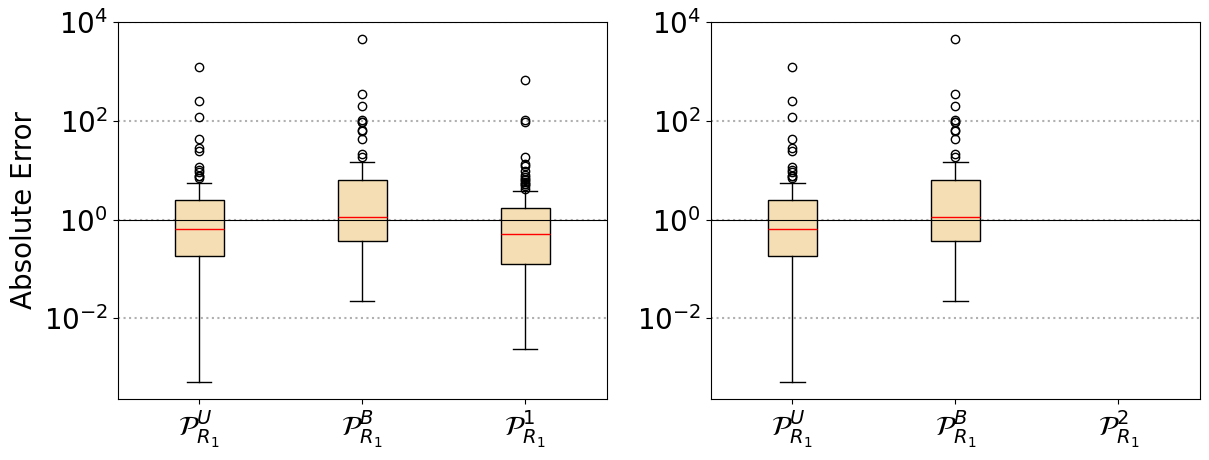

In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# Plot 1
p1_policies = np.delete(policies, 3)

ax1.boxplot(
    p1_data.T,
    tick_labels=p1_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax1.set_ylabel("Absolute Error")
ax1.set_yscale('log')
ax1.grid(axis='y', linestyle=':', linewidth=1.5)
ax1.axhline(1, color='black', linewidth=0.8)

# Plot 2
p2_policies = np.delete(policies, 2)

ax2.boxplot(
    p2_data.T,
    tick_labels=p2_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax2.set_yscale('log')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)
ax2.axhline(1, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# TPC-H Evaluation

## Relative Error Comparison for Q1, Q4, Q13, and Q16

In [23]:
plt.rcParams.update({'font.size': 20})

def read_noise(filepath):
    with open(filepath, newline='') as f:
        reader = csv.reader(f)
        data = []
        for row in reader:
            if not row:
                continue
            data.append(row[1:])    
        return data

In [65]:
customer_policies = np.array([r'$\mathcal{P}^U_{\bf{C\_}}$', r'$\mathcal{P}^1_{\bf{C\_}}$', r'$\mathcal{P}^2_{\bf{C\_}}$'])
supplier_policies = np.array([r'$\mathcal{P}^U_{\bf{S\_}}$', r'$\mathcal{P}^1_{\bf{S\_}}$', r'$\mathcal{P}^2_{\bf{S\_}}$'])

# Data
data = []
data.append(read_noise('tpch/q1_noise.csv'))
data.append(read_noise('tpch/q4_noise.csv'))
data.append(read_noise('tpch/q13_noise.csv'))
data.append(read_noise('tpch/q16_noise.csv'))
data = np.array(data).astype(float)

# Scaling for relative error
data[0, :, :] /= 1478493
data[1, :, :] /= 10594
data[2, :, :] /= 6641
data[3, :, :] /= 28

data.shape

(4, 6, 100)

### Q1

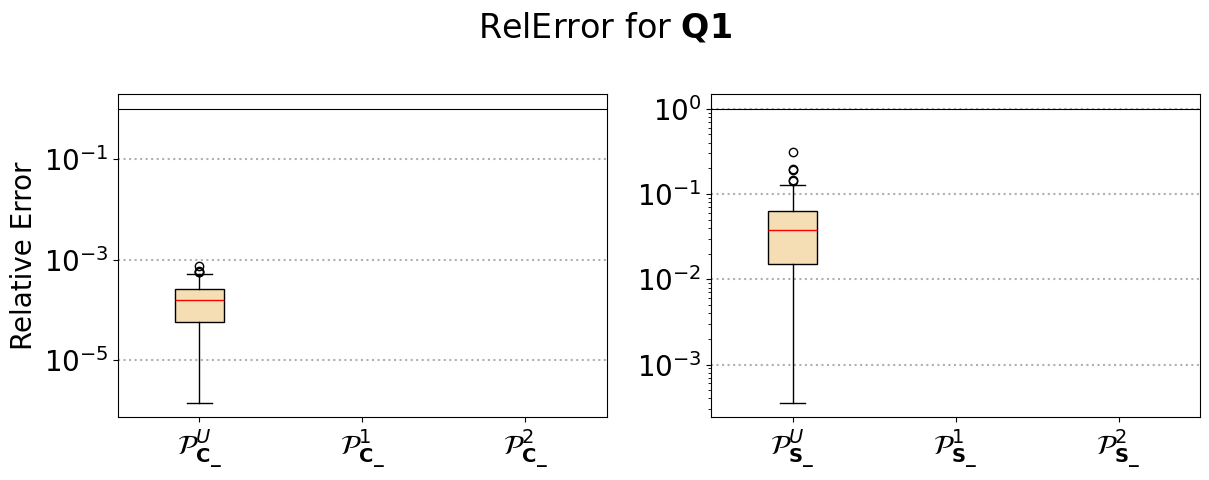

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# Q1
ax1.boxplot(
    data[0, 0:3, :].T,
    tick_labels=customer_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax1.set_ylabel("Relative Error")
ax1.set_yscale('log')
ax1.grid(axis='y', linestyle=':', linewidth=1.5)
ax1.axhline(1, color='black', linewidth=0.8)

ax2.boxplot(
    data[0, 3:, :].T,
    tick_labels=supplier_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax2.set_yscale('log')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)
ax2.axhline(1, color='black', linewidth=0.8)

fig.suptitle(r'RelError for $\bf{Q1}$')
plt.tight_layout()
plt.show()

### Q4

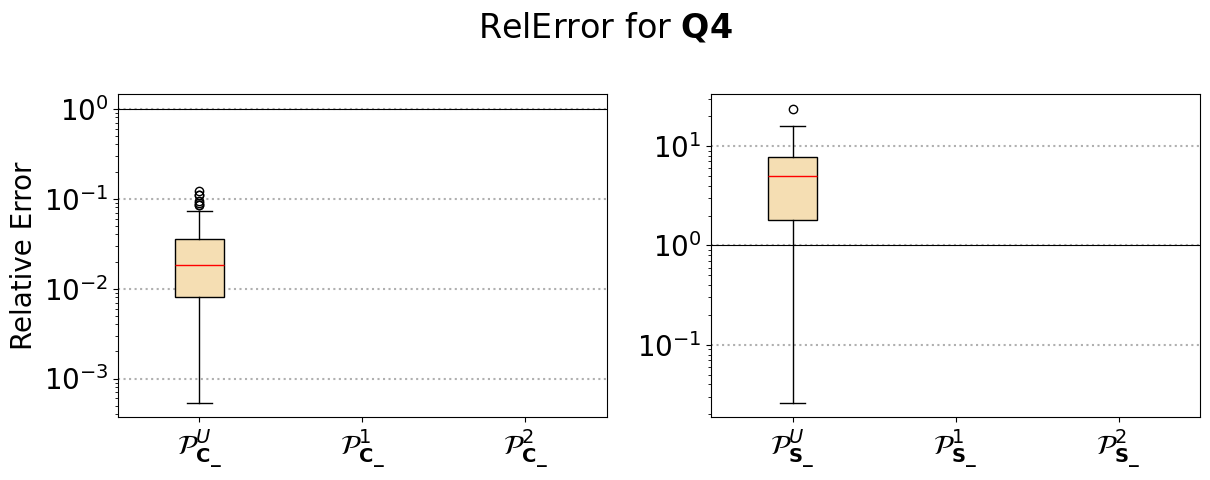

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# Q4
ax1.boxplot(
    data[1, 0:3, :].T,
    tick_labels=customer_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax1.set_ylabel("Relative Error")
ax1.set_yscale('log')
ax1.grid(axis='y', linestyle=':', linewidth=1.5)
ax1.axhline(1, color='black', linewidth=0.8)

ax2.boxplot(
    data[1, 3:, :].T,
    tick_labels=supplier_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax2.set_yscale('log')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)
ax2.axhline(1, color='black', linewidth=0.8)

fig.suptitle(r'RelError for $\bf{Q4}$')
plt.tight_layout()
plt.show()

### Q13 and Q16

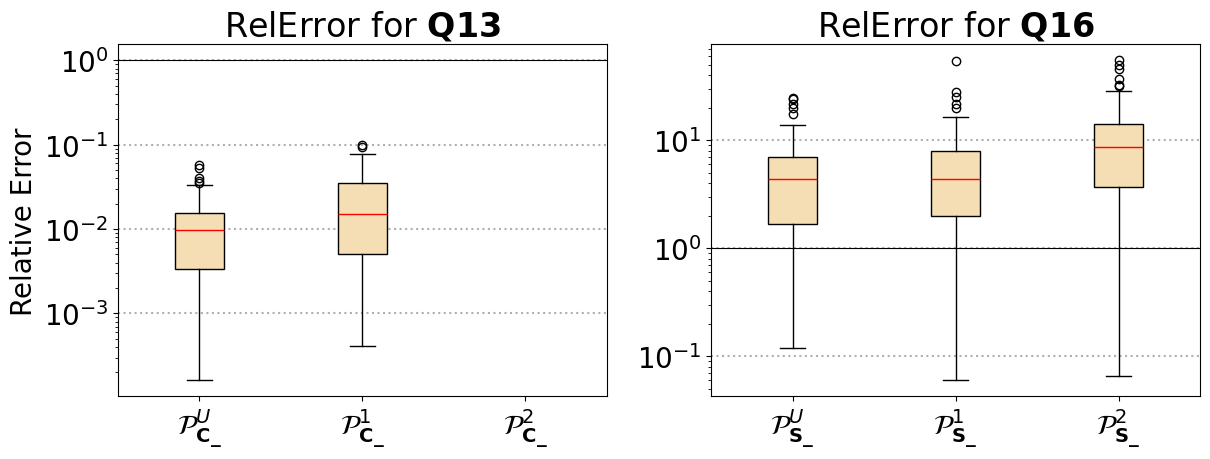

In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# Q13
ax1.boxplot(
    data[2, 0:3, :].T,
    tick_labels=customer_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax1.set_ylabel("Relative Error")
ax1.set_title(r'RelError for $\bf{Q13}$')
ax1.set_yscale('log')
ax1.grid(axis='y', linestyle=':', linewidth=1.5)
ax1.axhline(1, color='black', linewidth=0.8)

# Q16
ax2.boxplot(
    data[3, 3:, :].T,
    tick_labels=supplier_policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax2.set_yscale('log')
ax2.set_title(r'RelError for $\bf{Q16}$')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)
ax2.axhline(1, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()